In [1]:
import os
import sys

# Move up one directory to the project root and add it to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now your imports will work perfectly!
from src.data_loader import load_insurance_data, calculate_insurance_metrics
from src.eda_utils import get_missing_summary, plot_loss_ratio_by_dimension

In [2]:
# !pip install xgboost

In [3]:
# !pip install shap

In [4]:
# 2. Model Evaluation Execution 
# Execution Cell Sequence
import pandas as pd
import shap
import matplotlib.pyplot as plt
from src.data_loader import load_insurance_data
# from src.modeling import prepare_insurance_features, train_and_evaluate_regression
from src.modeling import train_and_evaluate_regression

# Load data assets
df = load_insurance_data('../data/MachineLearningRating_v3.zip')
from src.modeling import prepare_insurance_features, train_and_evaluate_regression
# Split data and target vectors
X_train, X_test, y_train, y_test = prepare_insurance_features(df, is_regression=True)

# Fit models and return comparative tables
metrics, best_xgb_model = train_and_evaluate_regression(X_train, X_test, y_train, y_test)
print(pd.DataFrame(metrics).T.to_markdown())


c:\Users\Almazt\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Personal\Kifiya 10 Academy\10 Academy\week 3 insurance-risk-analytics\src\data_loader.py:32: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(target_internal_file), sep=separator)


|                   |    RMSE |      R2 |
|:------------------|--------:|--------:|
| Linear Regression | 39983.4 |  0.006  |
| Random Forest     | 41988   | -0.0962 |
| XGBoost Regressor | 40652.4 | -0.0276 |


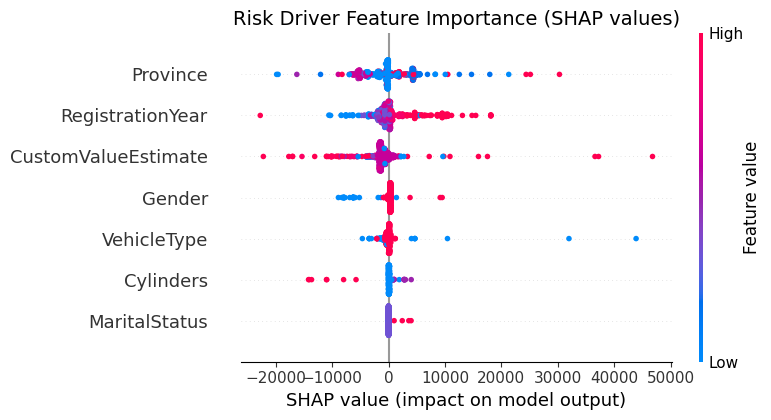

In [5]:
# 3. Model Interpretability with SHAP
# Calculate feature attributions using TreeSHAP
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer(X_test)

# Generate Summary Plot 
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Risk Driver Feature Importance (SHAP values)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/shap_importance_summary.png")
plt.show()
